In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("../data/student_profiles.csv")

df.head()

,Student_ID,Python,SQL,Excel,Statistics,Data Analysis,Machine Learning,Deep Learning,NLP,Power BI,...,JavaScript,HTML_CSS,C++,Git,Linux,Cloud,Cybersecurity,Communication,Problem Solving,Target_Career
0,S001,5,4,2,5,5,5,3,2,2,...,1,1,0,4,2,2,0,4,5,Data Scientist
1,S002,4,5,5,3,5,2,0,0,5,...,1,1,0,4,1,1,0,5,4,Data Analyst
2,S003,3,2,1,1,1,1,0,0,0,...,4,3,4,5,3,2,1,4,5,Software Developer
3,S004,2,2,1,0,1,0,0,0,0,...,5,5,0,4,2,2,0,4,4,Web Developer
4,S005,5,3,1,4,4,5,5,4,1,...,2,1,2,5,5,4,0,3,5,ML Engineer


In [4]:
df.shape

(40, 22)

In [5]:
X = df.drop(columns=["Student_ID", "Target_Career"])

y = df["Target_Career"]

In [6]:
y.value_counts()

Target_Career
Data Scientist           5
Data Analyst             5
Software Developer       5
Web Developer            5
ML Engineer              5
Business Analyst         5
Cybersecurity Analyst    5
Cloud Engineer           5
Name: count, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 32
Testing samples: 8


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [11]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [12]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

Logistic Regression Accuracy: 1.0


In [13]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

                       precision    recall  f1-score   support

     Business Analyst       1.00      1.00      1.00         1
       Cloud Engineer       1.00      1.00      1.00         1
Cybersecurity Analyst       1.00      1.00      1.00         1
         Data Analyst       1.00      1.00      1.00         1
       Data Scientist       1.00      1.00      1.00         1
          ML Engineer       1.00      1.00      1.00         1
   Software Developer       1.00      1.00      1.00         1
        Web Developer       1.00      1.00      1.00         1

             accuracy                           1.00         8
            macro avg       1.00      1.00      1.00         8
         weighted avg       1.00      1.00      1.00         8



In [14]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]


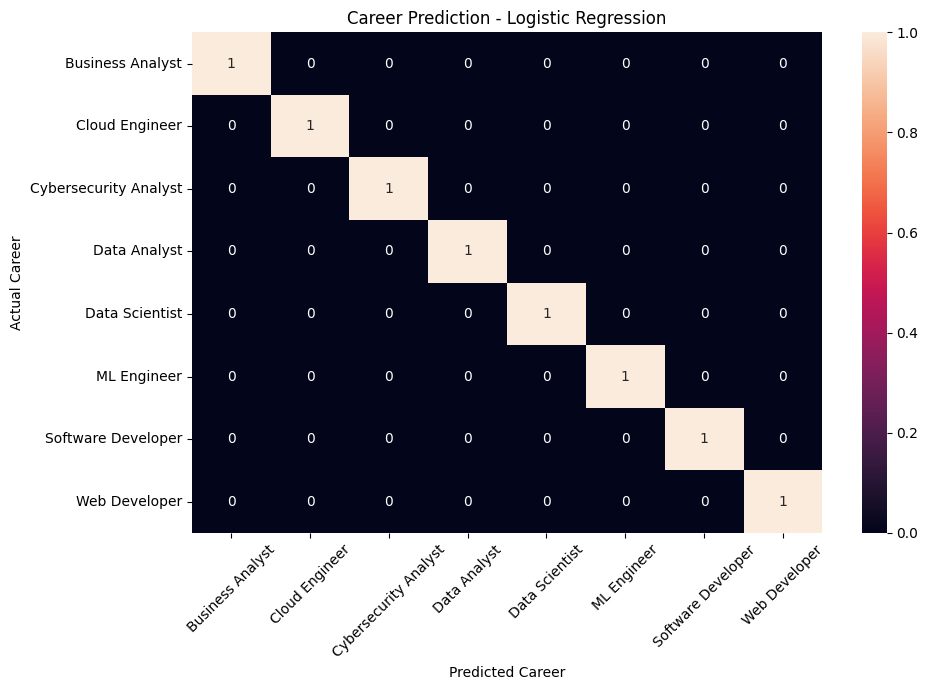

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.xlabel("Predicted Career")
plt.ylabel("Actual Career")
plt.title("Career Prediction - Logistic Regression")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_rf = rf_model.predict(X_test)

In [18]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [20]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:")
print(logistic_cv_scores)

print("Mean CV Accuracy:",
      logistic_cv_scores.mean())

print("Standard Deviation:",
      logistic_cv_scores.std())

Logistic Regression CV Scores:
[1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0
Standard Deviation: 0.0


In [23]:
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Random Forest CV Scores:")
print(rf_cv_scores)

print("Mean CV Accuracy:",
      rf_cv_scores.mean())

print("Standard Deviation:",
      rf_cv_scores.std())

Random Forest CV Scores:
[1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0
Standard Deviation: 0.0


In [24]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Std Deviation": [
        logistic_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_results

,Model,Mean CV Accuracy,Std Deviation
0,Logistic Regression,1.0,0.0
1,Random Forest,1.0,0.0


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.875


In [27]:
dt_cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Decision Tree CV Scores:")
print(dt_cv_scores)

print("Mean CV Accuracy:",
      dt_cv_scores.mean())

print("Standard Deviation:",
      dt_cv_scores.std())

Decision Tree CV Scores:
[1.    0.875 0.875 1.    1.   ]
Mean CV Accuracy: 0.95
Standard Deviation: 0.06123724356957946


In [28]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean(),
        dt_cv_scores.mean()
    ],
    "Std Deviation": [
        logistic_cv_scores.std(),
        rf_cv_scores.std(),
        dt_cv_scores.std()
    ]
})

final_results.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

,Model,Mean CV Accuracy,Std Deviation
0,Logistic Regression,1.00,0.000000
1,Random Forest,1.00,0.000000
2,Decision Tree,0.95,0.061237
